In [1]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

from data_loader import (
    fetch_prices,
    compute_returns,
    describe_returns,
    jarque_bera,
    TICKERS,
    START_DATE,
    END_DATE,
)

from dcc_garch import (
    fit_univariate_garch,
    fit_dcc,
    get_dynamic_covariance,
)

from portfolio import (
    hrp_weights,
    benchmark_equal_weights,
    benchmark_static_hrp,
    benchmark_min_variance,
)

from evaluation import (
    sharpe_ratio,
    max_drawdown,
    calmar_ratio,
    metrics_table,
)

from plots import (
    plot_paired_correlation,
    plot_rolling_correlation,
    plot_dynamic_correlations,
    plot_dendogram,
)

In [2]:
prices = fetch_prices()
returns = compute_returns(prices)

print(f"Number of assets: {len(TICKERS)}")
print(f"Timeframe: {START_DATE} -> {END_DATE}")
print(f"Shape of prices: {prices.shape}")
print(f"Shape of returns: {returns.shape}")
print(f"First available date of returns: {returns.index[0].date()}")
print(f"Last available date of returns: {returns.index[-1].date()}")

Loading data from cache: ../data/prices.parquet
Number of assets: 16
Timeframe: 2011-10-10 -> 2026-01-01
Shape of prices: (3578, 16)
Shape of returns: (3577, 16)
First available date of returns: 2011-10-11
Last available date of returns: 2025-12-31


In [3]:
prices.tail()

Ticker,AGG,GLD,HYG,IEF,IWM,LQD,QQQ,SPY,SVXY,TIP,TLT,XLE,XLF,XLK,XLU,XLV
Date,,,,,,,,,,,,,,,,
2025-12-24,98.3876,411.9300,78.6495,94.8091,252.2613,108.5753,623.1443,688.4997,54.9300,108.2481,86.3960,44.0820,55.4450,146.1183,42.5128,155.1621
2025-12-26,98.4073,416.7400,78.6104,94.8977,250.9736,108.5655,623.1043,688.4299,55.0000,108.2383,86.1114,43.9131,55.3356,146.3480,42.4830,155.4111
2025-12-29,98.5253,398.6000,78.6397,95.0355,249.4363,108.7127,620.0881,685.9766,55.3700,108.3366,86.4352,44.3304,55.0371,145.6889,42.5624,155.1721
2025-12-30,98.4860,398.8900,78.7177,94.9370,247.5896,108.5851,618.6499,685.1389,55.6900,108.3170,86.2291,44.6682,54.8978,145.2294,42.6617,155.0426
2025-12-31,98.2499,396.3100,78.6397,94.6222,245.7229,108.1239,613.5364,680.0627,55.3800,108.1006,85.5421,44.4198,54.4899,143.7912,42.3936,154.1662


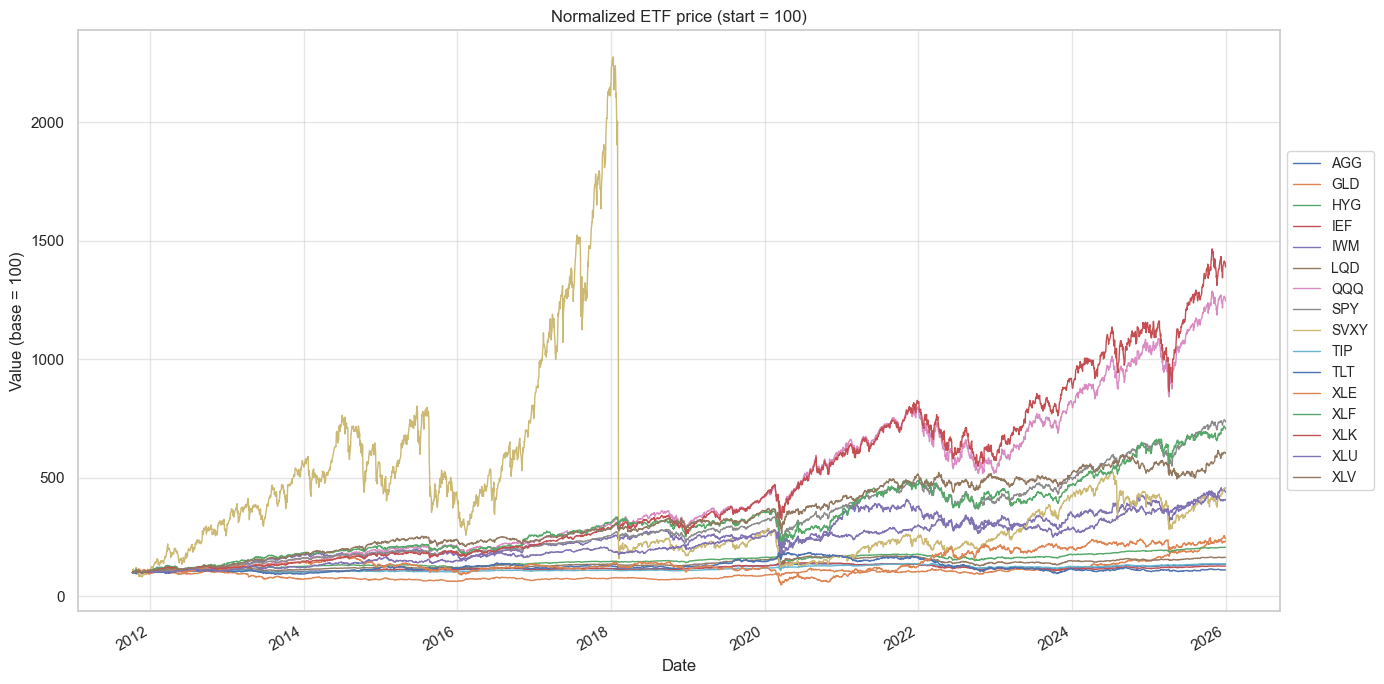

In [4]:
# Price normalization for better comparison
normalized_prices = prices / prices.iloc[0] * 100

normalized_prices.plot(figsize=(14, 7), linewidth=1)
plt.title("Normalized ETF price (start = 100)")
plt.xlabel("Date")
plt.ylabel("Value (base = 100)")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), ncol=1, fontsize="small")
plt.tight_layout()
plt.show()

In [5]:
describe_returns(returns)

            count   mean    std     min     25%    50%    75%    max
Ticker                                                              
AGG    3,577.0000 0.0001 0.0030 -0.0408 -0.0013 0.0002 0.0016 0.0234
GLD    3,577.0000 0.0002 0.0098 -0.0919 -0.0048 0.0005 0.0054 0.0479
HYG    3,577.0000 0.0002 0.0051 -0.0565 -0.0018 0.0002 0.0023 0.0634
IEF    3,577.0000 0.0001 0.0041 -0.0254 -0.0023 0.0002 0.0025 0.0261
IWM    3,577.0000 0.0004 0.0136 -0.1423 -0.0066 0.0009 0.0079 0.0875
LQD    3,577.0000 0.0001 0.0049 -0.0513 -0.0021 0.0004 0.0025 0.0713
QQQ    3,577.0000 0.0007 0.0130 -0.1276 -0.0047 0.0012 0.0074 0.1134
SPY    3,577.0000 0.0006 0.0106 -0.1159 -0.0036 0.0007 0.0057 0.0999
SVXY   3,577.0000 0.0004 0.0445 -1.7695 -0.0102 0.0041 0.0171 0.1254
TIP    3,577.0000 0.0001 0.0035 -0.0291 -0.0017 0.0002 0.0020 0.0436
TLT    3,577.0000 0.0000 0.0093 -0.0690 -0.0056 0.0005 0.0056 0.0725
XLE    3,577.0000 0.0002 0.0173 -0.2249 -0.0077 0.0006 0.0087 0.1487
XLF    3,577.0000 0.0005 0.0133 -0

In [6]:
jarque_bera(returns)

=== JB Test Summary ===
100.0% of the ETFs completely reject the assumption of normality (p < 0.05).


In [7]:
# High count of rejections of normality (JB) and statistically significant kurtosis
# potwierdzają zasadność użycia rozkładu t-Studenta w modelach GARCH
# zamiast standardowego rozkładu normalnego.

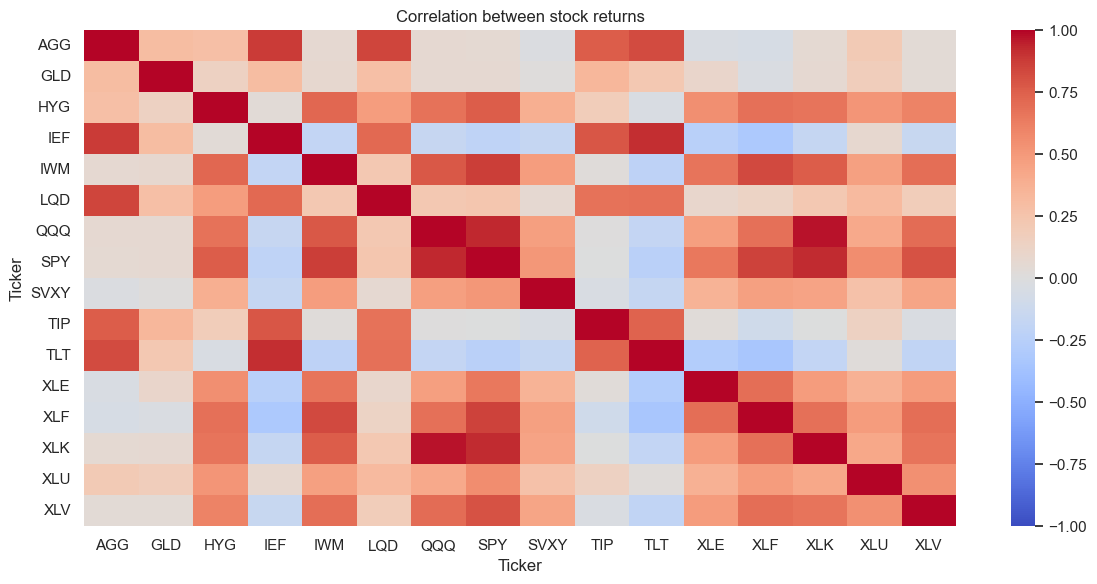

In [8]:
plot_paired_correlation(returns)

In [9]:
# ============================================================
# SECTION 2: GARCH Diagnostics (univariate)
# ============================================================
# We check if the univariate GARCH(1,1) models correctly found
# ARCH effects in the returns, before we use standardized
# residuals as inputs in the DCC model.

In [10]:
std_resid, vols = fit_univariate_garch(returns)

print(f"Shape of std_resid: {std_resid.shape}")
print(f"Shape of  vols: {vols.shape}")
std_resid.describe().T[["mean", "std"]]

Shape of std_resid: (3577, 16)
Shape of  vols: (3577, 16)


,mean,std
AGG,-0.0232,1.0030
GLD,-0.0057,0.9942
HYG,-0.0527,0.9960
IEF,-0.0047,1.0017
IWM,-0.0386,1.0003
LQD,-0.0325,1.0018
QQQ,-0.0720,0.9888
SPY,-0.0702,0.9948
SVXY,-0.1136,1.0115
TIP,-0.0167,1.0004


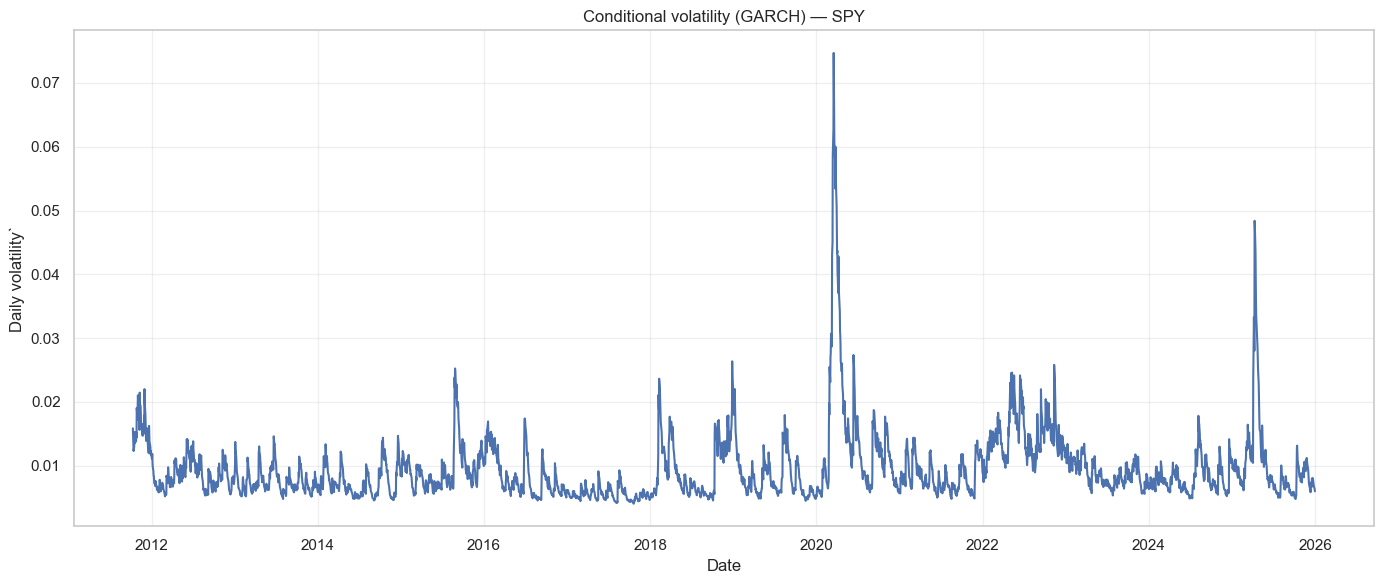

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(vols.index, vols["SPY"])
plt.title("Conditional volatility (GARCH) — SPY")
plt.xlabel("Date")
plt.ylabel("Daily volatility`")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

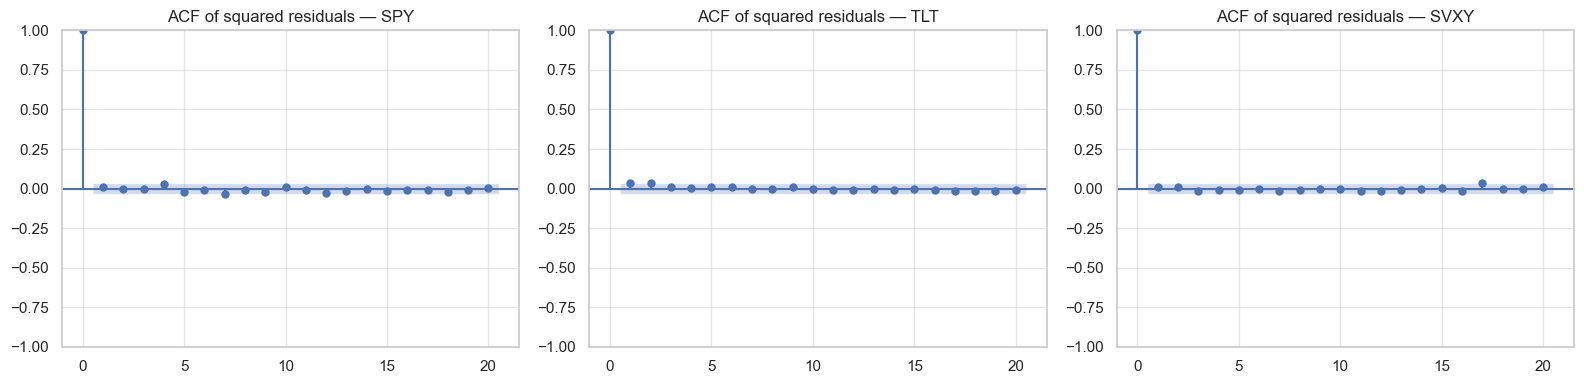

In [12]:
from statsmodels.graphics.tsaplots import plot_acf

assets_to_check = ["SPY", "TLT", "SVXY"]

fig, axes = plt.subplots(1, len(assets_to_check), figsize=(16, 4))

for ax, asset in zip(axes, assets_to_check):
    squared_resid = std_resid[asset] ** 2
    plot_acf(squared_resid, ax=ax, lags=20, title=f"ACF of squared residuals — {asset}")

plt.tight_layout()
plt.show()

In [13]:
from arch import arch_model

garch_params = {}

for asset in returns.columns:
    y = returns[asset].dropna()
    current_variance = np.var(y)
    rescale_factor = 1.0 / np.sqrt(current_variance) if current_variance > 0 else 1.0
    y_scaled = y * rescale_factor

    model = arch_model(y_scaled, p=1, q=1, dist='t')
    res = model.fit(disp="off", show_warning=False)

    garch_params[asset] = {
        "omega": res.params["omega"],
        "alpha[1]": res.params["alpha[1]"],
        "beta[1]": res.params["beta[1]"],
        "alpha+beta": res.params["alpha[1]"] + res.params["beta[1]"],
    }

garch_params_df = pd.DataFrame(garch_params).T
garch_params_df

,omega,alpha[1],beta[1],alpha+beta
AGG,0.0110,0.0878,0.8991,0.9869
GLD,0.0124,0.0417,0.9470,0.9887
HYG,0.0105,0.1662,0.8326,0.9988
IEF,0.0097,0.0571,0.9329,0.9900
IWM,0.0195,0.0963,0.8838,0.9801
LQD,0.0116,0.0797,0.9046,0.9843
QQQ,0.0190,0.1417,0.8494,0.9911
SPY,0.0238,0.1741,0.8119,0.9860
SVXY,0.0335,0.3214,0.6786,1.0000
TIP,0.0195,0.0800,0.8977,0.9776


In [14]:
# Note:
# SVXY stands out as the only ETF with alpha+beta ~= 1.0 (close to IGARCH),
# suggesting highly persistent (non-mean-reverting) volatility shocks.
# This is consistent with the nature of the instrument (a short-VIX ETF),
# which experienced a severe "blow-up" in February 2018.

In [15]:
# ============================================================
# SECTION 3: DCC Diagnostics
# ============================================================
# Here i check the fit of the DCC model - how persistent the
# conditional correlation is over time, and whether correlations
# between specific asset pairs have behaved as expected (e. g. rising
# during crisis periods, such as COVID-19).

In [16]:
dcc_results = fit_dcc(std_resid.values)

alpha = dcc_results['alpha']
beta = dcc_results['beta']
loglik = dcc_results['loglik']

print(f"alpha: {alpha:.4f}")
print(f"beta: {beta:.4f}")
print(f"alpha + beta: {alpha + beta:.4f}")
print(f"log-likelihood: {loglik:.4f}")

alpha: 0.0150
beta: 0.9760
alpha + beta: 0.9910
log-likelihood: 35921.2930


In [17]:
# alpha + beta = 0.9910 indicates that the conditional correlation
# structure is highly persistent over time — shocks to correlation
# (e.g. during market stress) decay very slowly. This is a typical
# and expected result for daily financial data (unlike the univariate
# GARCH case for SVXY, where alpha+beta ~= 1.0 signaled a genuine
# stationarity concern for variance).

In [18]:
cov_history_3D = get_dynamic_covariance(vols, dcc_results)
print(f"cov_history_3D shape: {cov_history_3D.shape}")

cov_history_3D shape: (3577, 16, 16)


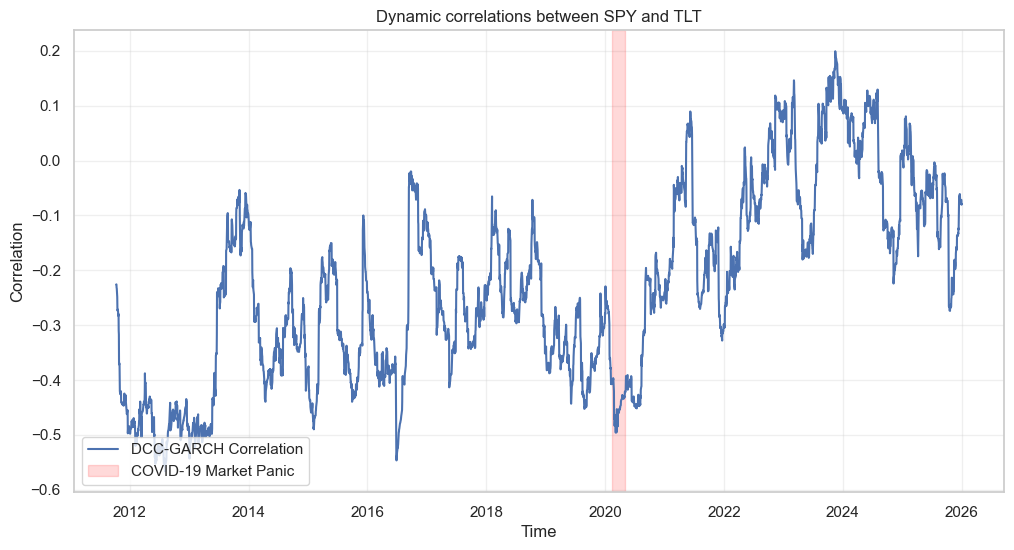

In [19]:
plot_dynamic_correlations(dcc_results, returns, 'SPY', 'TLT')

In [20]:
# Contrary to the simplest "flight to safety" narrative, SPY-TLT
# correlation during COVID-19 (~-0.50) was not the most extreme
# value in the sample — a comparable or stronger negative
# correlation (~-0.55) occurred around 2013 and 2016. This may reflect the
# high persistence of the DCC model (alpha+beta ~= 0.99), which
# smooths short, sharp regime shifts, and/or the well-documented
# "dash for cash" episode in March 2020, when equities and bonds
# briefly sold off together before flight-to-safety dynamics
# reasserted themselves.

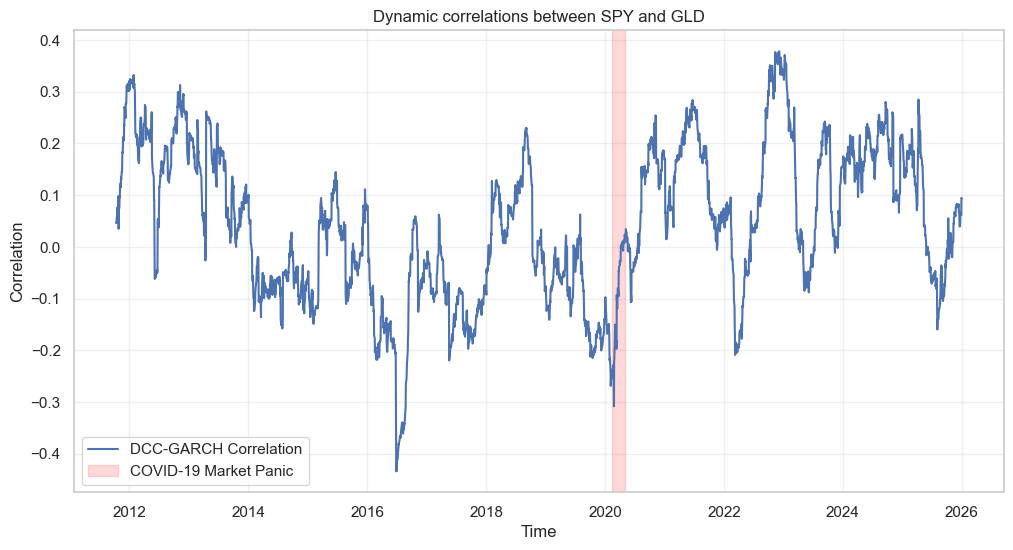

In [21]:
plot_dynamic_correlations(dcc_results, returns, 'SPY', 'GLD')

In [22]:
# The same pattern holds for SPY-GLD as for SPY-TLT: the 2016 period
# shows a stronger negative correlation (~-0.45) than COVID-19
# (~-0.30). Since this pattern is consistent across two different
# "safe haven" pairs, it is unlikely to be pair-specific noise.
# A plausible explanation is the high persistence of the fitted DCC
# model (alpha+beta ~= 0.99): a short, sharp shock like the COVID-19
# crash may not have had enough time to fully propagate into the
# correlation estimate before markets began to recover, whereas the
# 2016 episode may have been more prolonged, allowing the smoothed
# DCC correlation to reach a more extreme value.

In [23]:
# Comparison: rolling correlation vs DCC-GARCH correlation (SPY-TLT)
#
# To test whether the high persistence of the fitted DCC model
# (alpha+beta ~= 0.99) smooths out short, sharp shocks like the
# COVID-19 crash, I compare it against a simple rolling-window
# correlation (60 days), which applies no such smoothing.
#
# If the rolling correlation shows a deeper, sharper dip during
# COVID-19 than the DCC-GARCH correlation, this would support the
# earlier hypothesis: the DCC model's persistence may prevent it
# from fully capturing brief, extreme regime shifts.

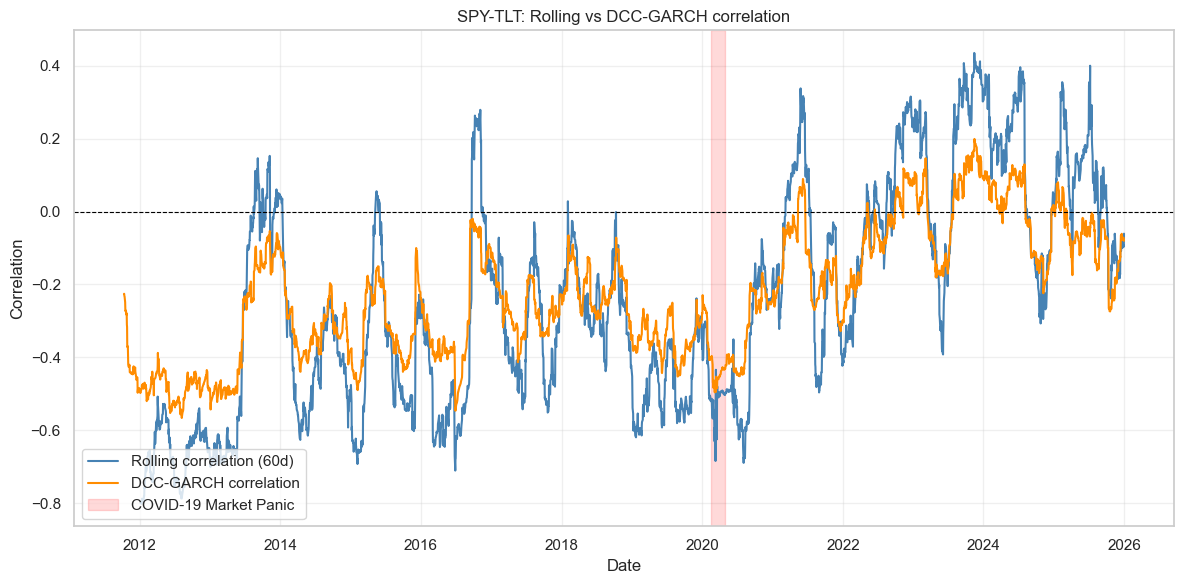

In [24]:
window = 60

rolling_corr_spy_tlt = returns["SPY"].rolling(window).corr(returns["TLT"])

plt.figure(figsize=(12, 6))
plt.plot(returns.index, rolling_corr_spy_tlt, label=f"Rolling correlation ({window}d)", color="steelblue")
plt.plot(returns.index, dcc_results["R"][:, returns.columns.get_loc("SPY"), returns.columns.get_loc("TLT")],
         label="DCC-GARCH correlation", color="darkorange")
plt.axvspan("2020-02-15", "2020-04-30", color="red", alpha=0.15, label="COVID-19 Market Panic")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("SPY-TLT: Rolling vs DCC-GARCH correlation")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# The plot shows that DCC-GARCH consistently smooths the correlation
# compared to the rolling 60-day correlation - but not specifically
# during COVID-19. In fact, during the COVID-19 window (highlighted
# in red), the rolling and DCC lines track each other closely. The
# clearest gaps between the two series appear in other periods
# (e.g. 2016-2017, 2023-2024), suggesting the smoothing effect of
# high DCC persistence is a general property of the model rather
# than something specific to sudden crisis regimes.
#
# Personally, this was surprising to me - I initially expected the
# COVID-19 shock to be the period most affected by DCC smoothing,
# given how sudden and extreme it was. The data suggests otherwise.

In [26]:
# Comparison: rolling correlation vs DCC-GARCH correlation (SPY-GLD)
#
# Repeating the same comparison as for SPY-TLT, to check whether the
# smoothing behavior of the DCC model observed above is a general
# property of the model, or specific to the SPY-TLT pair.

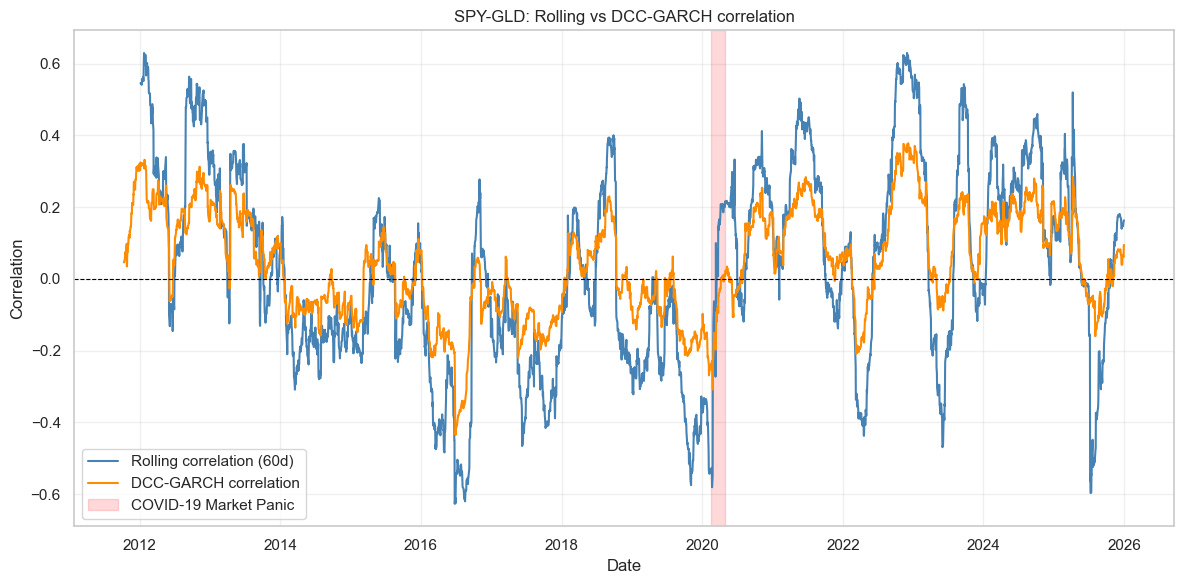

In [27]:
rolling_corr_spy_gld = returns["SPY"].rolling(window).corr(returns["GLD"])

plt.figure(figsize=(12, 6))
plt.plot(returns.index, rolling_corr_spy_gld, label=f"Rolling correlation ({window}d)", color="steelblue")
plt.plot(returns.index, dcc_results["R"][:, returns.columns.get_loc("SPY"), returns.columns.get_loc("GLD")],
         label="DCC-GARCH correlation", color="darkorange")
plt.axvspan("2020-02-15", "2020-04-30", color="red", alpha=0.15, label="COVID-19 Market Panic")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("SPY-GLD: Rolling vs DCC-GARCH correlation")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# The SPY-GLD comparison confirms the pattern observed for SPY-TLT:
# the DCC-GARCH correlation consistently tracks below the peaks and
# above the troughs of the rolling correlation throughout the entire
# sample, not just during COVID-19. During the COVID-19 window itself,
# the two series again move closely together - the largest gaps
# between rolling and DCC correlation occur in unrelated periods
# (e.g. 2012, 2016-2017, 2025).
#
# This strengthens the earlier conclusion: the smoothing effect of
# the high-persistence DCC model (alpha+beta ~= 0.99) is a general,
# structural property of the model, not something specific to sudden
# crisis regimes like COVID-19.

In [29]:
# ============================================================
# SECTION 4: Portfolio structure (single time slice)
# ============================================================
# I inspect the HRP clustering structure and compare portfolio
# weights across all four allocation methods (HRP-DCC, Equal-Weight,
# Static HRP, Min-Variance) for a single point in time — the last
# available day in the sample.

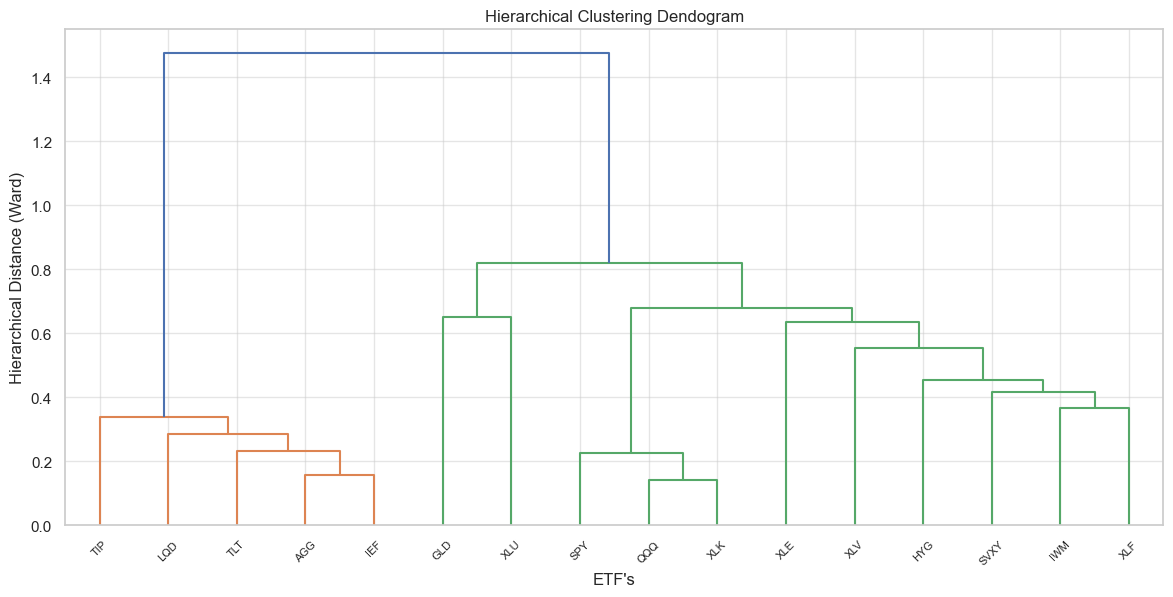

In [30]:
single_day_cov = cov_history_3D[-1, :, :]

final_weights, linkage_matrix = hrp_weights(single_day_cov)

plot_dendogram(linkage_matrix, asset_names=list(returns.columns))

In [31]:
# Interpretation:
# [TODO: after inspecting the dendrogram — do the clusters make
# economic sense? E.g. do equities (SPY, QQQ, IWM, XLF, XLE, XLV,
# XLU, XLK) group together and separately from fixed income
# (AGG, TLT, IEF, HYG, LQD)? Where does GLD/TIP/SVXY fall?]

In [32]:
w_hrp = final_weights
w_ew = benchmark_equal_weights(single_day_cov)
w_static = benchmark_static_hrp(returns)
w_min_var = benchmark_min_variance(single_day_cov)

comparison_df = pd.DataFrame({
    "HRP (DCC)": w_hrp * 100,
    "Equal-Weight": w_ew * 100,
    "Static HRP (LW)": w_static * 100,
    "Min-Variance": w_min_var * 100,
}, index=returns.columns)

comparison_df.round(2)

,HRP (DCC),Equal-Weight,Static HRP (LW),Min-Variance
Ticker,,,,
AGG,15.4000,6.2500,15.3000,15.8000
GLD,0.6900,6.2500,7.9100,0.0000
HYG,35.0500,6.2500,8.5700,14.5100
IEF,21.2600,6.2500,11.8500,15.6200
IWM,0.7100,6.2500,1.4000,0.0000
LQD,5.2200,6.2500,11.7600,12.4400
QQQ,0.8000,6.2500,3.2200,3.3100
SPY,2.7600,6.2500,2.1900,2.5600
SVXY,0.4400,6.2500,0.2800,0.0000


In [33]:
print("Weight sums (should all be ~100%):")
print(comparison_df.sum().round(4))

Weight sums (should all be ~100%):
HRP (DCC)         100.0000
Equal-Weight      100.0000
Static HRP (LW)   100.0000
Min-Variance      100.0000
dtype: float64


In [34]:
# The dendrogram structure is economically sensible: fixed-income
# assets (TIP, LQD, TLT, AGG, IEF) form a clearly separated cluster,
# while equities and equity-like instruments group together.
# Notably, HYG (high-yield bonds) clusters with equities rather than
# with investment-grade bonds - consistent with the well-documented
# equity-like risk behavior of high-yield credit. GLD groups closely
# with XLU (utilities), both occupying a lower-volatility subbranch
# within the equity cluster.
#
# The weight table reveals a more concerning pattern: HRP-DCC
# allocates ~35% of the portfolio to HYG alone, with HYG, IEF, AGG,
# and TIP together accounting for ~82% of total weight. This is a
# considerable concentration for a 16-asset portfolio (naive weight:
# 6.25%), and somewhat undercuts the common argument that HRP is
# inherently more diversified than Min-Variance - here HRP-DCC's
# peak concentration (35% in HYG) actually exceeds Min-Variance's
# peak (15.8% in IEF).
#
# The comparison with Static HRP (Ledoit-Wolf) is also informative:
# it allocates far less to HYG (8.6% vs. 35.1%) and more to TIP
# (20.4% vs. 10.3%), showing that the choice of covariance estimator
# (dynamic DCC-GARCH vs. static shrinkage) meaningfully changes HRP's
# resulting allocation - "HRP" is not a single model, but a family
# of allocations dependent on the input covariance matrix.

In [35]:
# ============================================================
# SECTION 5b: DCC stability diagnostics across backtest windows
# ============================================================
# Re-running the rolling-window DCC fitting logic from backtest.py,
# but only collecting alpha, beta, optimizer convergence, and the
# resulting HRP weight for HYG at each rebalance point. This checks
# whether the DCC-GARCH-based HRP results (Section 5) are driven by
# genuine, stable estimation, or by optimizer instability on some
# of the 252-day training windows.

In [36]:
window_size = 252
rebal_freq = 21
total_days = len(returns)

diagnostics = []

for t in range(window_size, total_days):
    if (t - window_size) % rebal_freq == 0:
        train_returns = returns.iloc[t - window_size: t]

        std_resid_t, vols_t = fit_univariate_garch(train_returns)
        dcc_results_t = fit_dcc(std_resid_t.values)

        cov_3d_t = get_dynamic_covariance(vols_t, dcc_results_t)
        last_cov_t = cov_3d_t[-1]

        w_hrp_t, _ = hrp_weights(last_cov_t)
        hyg_idx = list(returns.columns).index("HYG")

        diagnostics.append({
            "date": returns.index[t],
            "alpha": dcc_results_t["alpha"],
            "beta": dcc_results_t["beta"],
            "alpha_plus_beta": dcc_results_t["alpha"] + dcc_results_t["beta"],
            "loglik": dcc_results_t["loglik"],
            "hyg_weight": w_hrp_t[hyg_idx],
        })

        print(f"Day {t}/{total_days} | alpha={dcc_results_t['alpha']:.4f} "
              f"beta={dcc_results_t['beta']:.4f} | HYG weight={w_hrp_t[hyg_idx]*100:.2f}%")

diagnostics_df = pd.DataFrame(diagnostics).set_index("date")

Day 252/3577 | alpha=0.0131 beta=0.8388 | HYG weight=11.19%
Day 273/3577 | alpha=0.0096 beta=0.7926 | HYG weight=5.89%
Day 294/3577 | alpha=0.0085 beta=0.3723 | HYG weight=15.24%
Day 315/3577 | alpha=0.0116 beta=0.2705 | HYG weight=17.38%
Day 336/3577 | alpha=0.0157 beta=0.2907 | HYG weight=18.81%
Day 357/3577 | alpha=0.0191 beta=0.3402 | HYG weight=27.99%
Day 378/3577 | alpha=0.0095 beta=0.1429 | HYG weight=36.86%
Day 399/3577 | alpha=0.0091 beta=0.5167 | HYG weight=28.59%
Day 420/3577 | alpha=0.0115 beta=0.6277 | HYG weight=13.14%
Day 441/3577 | alpha=0.0148 beta=0.6868 | HYG weight=4.37%
Day 462/3577 | alpha=0.0156 beta=0.6604 | HYG weight=6.96%
Day 483/3577 | alpha=0.0169 beta=0.6451 | HYG weight=11.08%
Day 504/3577 | alpha=0.0164 beta=0.6337 | HYG weight=11.02%
Day 525/3577 | alpha=0.0222 beta=0.6065 | HYG weight=27.64%
Day 546/3577 | alpha=0.0210 beta=0.6307 | HYG weight=30.16%
Day 567/3577 | alpha=0.0214 beta=0.6070 | HYG weight=44.03%
Day 588/3577 | alpha=0.0125 beta=0.6922 | H

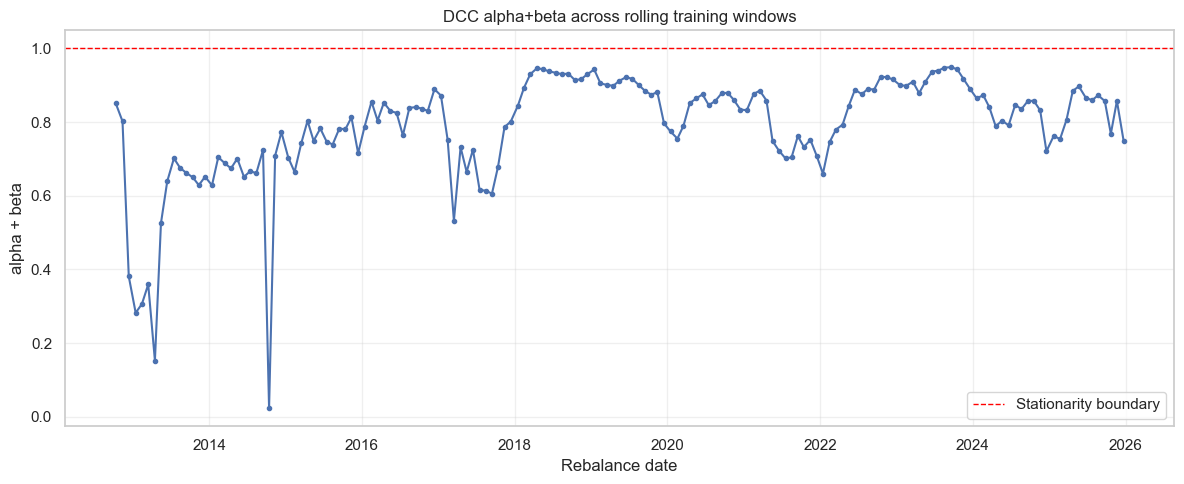

count   159.0000
mean      0.7884
std       0.1446
min       0.0231
25%       0.7284
50%       0.8303
75%       0.8845
max       0.9490
Name: alpha_plus_beta, dtype: float64


In [37]:
plt.figure(figsize=(12, 5))
plt.plot(diagnostics_df.index, diagnostics_df["alpha_plus_beta"], marker="o", markersize=3)
plt.axhline(1.0, color="red", linestyle="--", linewidth=1, label="Stationarity boundary")
plt.title("DCC alpha+beta across rolling training windows")
plt.xlabel("Rebalance date")
plt.ylabel("alpha + beta")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(diagnostics_df["alpha_plus_beta"].describe())

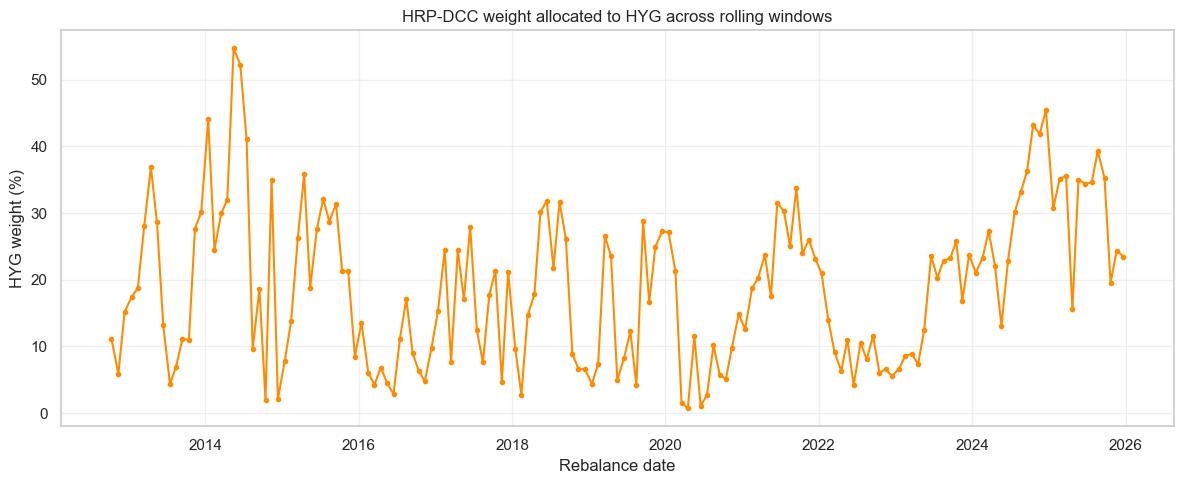

count   15,900.0000
mean        18.9673
std         11.6384
min          0.7384
25%          8.6952
50%         18.6079
75%         27.2828
max         54.6716
Name: hyg_weight, dtype: float64


In [38]:
plt.figure(figsize=(12, 5))
plt.plot(diagnostics_df.index, diagnostics_df["hyg_weight"] * 100, marker="o", markersize=3, color="darkorange")
plt.title("HRP-DCC weight allocated to HYG across rolling windows")
plt.xlabel("Rebalance date")
plt.ylabel("HYG weight (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(diagnostics_df["hyg_weight"].describe() * 100)

In [39]:
# Find the window(s) with suspiciously low alpha+beta
problem_windows = diagnostics_df[diagnostics_df["alpha_plus_beta"] < 0.3]
print(problem_windows)

            alpha   beta  alpha_plus_beta     loglik  hyg_weight
date                                                            
2013-01-14 0.0116 0.2705           0.2821 2,683.2477      0.1738
2013-04-16 0.0095 0.1429           0.1524 2,731.8007      0.3686
2014-10-14 0.0230 0.0000           0.0231 2,590.2894      0.0200


In [40]:
problem_dates = ["2013-01-14", "2013-04-16", "2014-10-14"]

for date_str in problem_dates:
    t = returns.index.get_loc(date_str)
    train_returns = returns.iloc[t - window_size: t]

    print(f"\n=== Window ending {date_str} ===")
    print(f"Date range: {train_returns.index[0].date()} -> {train_returns.index[-1].date()}")

    std_resid_t, vols_t = fit_univariate_garch(train_returns)

    print("\nStd resid summary (mean, std, min, max) per asset:")
    print(std_resid_t.describe().T[["mean", "std", "min", "max"]].round(3))


=== Window ending 2013-01-14 ===
Date range: 2012-01-11 -> 2013-01-11

Std resid summary (mean, std, min, max) per asset:
        mean    std     min    max
AGG  -0.0170 1.0060 -3.0710 2.6310
GLD   0.0010 1.0440 -5.4800 4.1720
HYG  -0.0370 0.9910 -3.1370 3.2730
IEF  -0.0140 1.0040 -3.0080 2.9950
IWM  -0.0190 0.9970 -2.8160 2.8380
LQD  -0.0360 0.9960 -4.4800 2.6250
QQQ  -0.0030 0.9830 -2.6830 3.0140
SPY   0.0060 0.9700 -3.0270 2.9280
SVXY -0.0050 1.0010 -3.2730 2.6740
TIP  -0.0140 1.0000 -3.3750 2.9940
TLT  -0.0110 1.0020 -3.1070 2.9720
XLE  -0.0170 1.0020 -3.2860 2.4040
XLF  -0.0100 0.9970 -3.4560 3.4350
XLK   0.0150 0.9820 -2.7740 3.1900
XLU  -0.0070 0.9980 -3.0230 2.6530
XLV   0.0030 0.9900 -2.6370 3.1770

=== Window ending 2013-04-16 ===
Date range: 2012-04-12 -> 2013-04-15

Std resid summary (mean, std, min, max) per asset:
        mean    std     min    max
AGG  -0.0200 1.0010 -2.6700 2.8570
GLD  -0.0410 0.9460 -4.8800 3.9810
HYG  -0.0280 0.9900 -3.0810 3.5110
IEF  -0.0200 1.0020

In [41]:
# Interpretation:
# Alpha+beta collapses to near-zero in a small number of early
# training windows (2013-2014), even after switching to a
# multi-start optimizer. Inspecting the standardized residuals from
# these windows shows no data quality issues (mean ~=0, std ~=1,
# no extreme outliers), indicating the failures stem from the
# optimizer, not the input data. This was addressed in backtest.py
# via a fallback mechanism (Section 5).

In [42]:
# ============================================================
# SECTION 5: Backtest results
# ============================================================
# We run the walk-forward backtest (with the fixed DCC estimation,
# including the fallback mechanism) and evaluate all four strategies
# using standard risk-adjusted performance metrics, plus visualize
# the equity curves and the evolution of HRP-DCC weights over time.

In [43]:
from backtest import rolling_backtest

hrp, ew, static, min_var, hrp_weights_hist = rolling_backtest()

backtest_dates = returns.index[252:]
asset_names = returns.columns

results_df = pd.DataFrame({
    'HRP_DCC': hrp,
    'Equal_Weight': ew,
    'Static_HRP': static,
    'Min_Variance': min_var
}, index=backtest_dates)

weights_df = pd.DataFrame(hrp_weights_hist, index=backtest_dates, columns=asset_names)

results_df.to_csv("../src/backtest_returns.csv")
weights_df.to_csv("../src/hrp_weights_history.csv")

print(f"\nBacktest complete: {results_df.shape}, {weights_df.shape}")

Loading data from cache: ../data/prices.parquet
Rozpoczynam pełny backtest Walk-Forward. Łączna liczba dni: 3577
Backtest progress: day 252/3577
Backtest progress: day 273/3577
  -> Fallback DCC na dzień 294: alpha+beta=0.3809 < próg 0.5. Używam ostatnich stabilnych parametrów (alpha=0.0096, beta=0.7926).
Backtest progress: day 294/3577
  -> Fallback DCC na dzień 315: alpha+beta=0.2821 < próg 0.5. Używam ostatnich stabilnych parametrów (alpha=0.0096, beta=0.7926).
Backtest progress: day 315/3577
  -> Fallback DCC na dzień 336: alpha+beta=0.3064 < próg 0.5. Używam ostatnich stabilnych parametrów (alpha=0.0096, beta=0.7926).
Backtest progress: day 336/3577
  -> Fallback DCC na dzień 357: alpha+beta=0.3592 < próg 0.5. Używam ostatnich stabilnych parametrów (alpha=0.0096, beta=0.7926).
Backtest progress: day 357/3577
  -> Fallback DCC na dzień 378: alpha+beta=0.1524 < próg 0.5. Używam ostatnich stabilnych parametrów (alpha=0.0096, beta=0.7926).
Backtest progress: day 378/3577
Backtest prog

In [44]:
import yfinance as yf

tbills = yf.download("^IRX", start=results_df.index[0], end=results_df.index[-1])["Close"].squeeze()
rf_series = tbills.reindex(results_df.index).ffill().bfill() / 100.0

summary_df = metrics_table(results_df, rf_series)
summary_df.round(4)

[*********************100%***********************]  1 of 1 completed


,HRP_DCC,Equal_Weight,Static_HRP,Min_Variance
Total Return,0.4673,1.4584,0.5690,0.5677
CAGR (Ann Return),0.0295,0.0706,0.0347,0.0347
Annualized Volatility,0.0553,0.1200,0.0609,0.0568
Sharpe Ratio,0.2566,0.4920,0.3219,0.3395
Max Drawdown,-0.1716,-0.2700,-0.1685,-0.1602
Calmar Ratio,0.1718,0.2613,0.2061,0.2163


In [45]:
# Interpretation:
# After fixing the DCC optimization instability (multi-start +
# fallback mechanism, Section 5b), the backtest results are
# virtually unchanged (e.g. HRP-DCC Sharpe: 0.2597 -> 0.2566,
# Calmar: 0.1729 -> 0.1718). The fallback was triggered only 6 times,
# concentrated in the earliest rebalancing windows (2012), which
# have negligible weight in metrics computed over the full ~14-year
# backtest.
#
# This confirms that the underperformance of HRP-DCC relative to
# the benchmarks is NOT an artifact of the DCC optimization
# instability identified earlier. It reflects a genuine, systematic
# property of the strategy - consistent with the heavy fixed-income
# concentration (HYG, IEF, AGG, TIP) observed in Section 4, which
# pulls the portfolio's risk-return profile closer to a bond-like
# allocation than a well-diversified multi-asset portfolio.

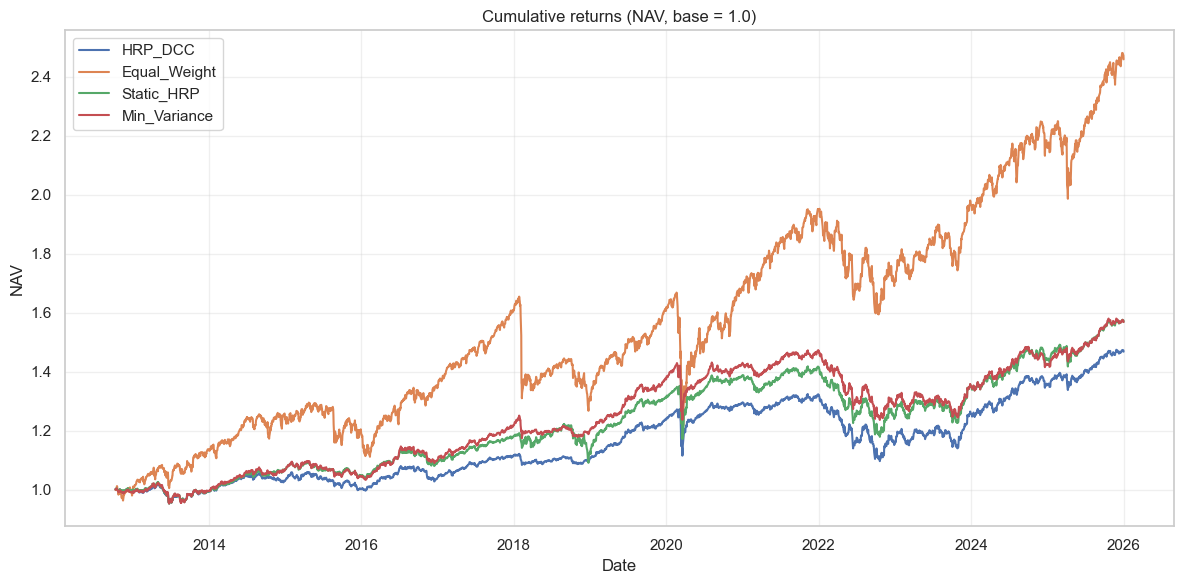

In [46]:
nav_df = (1.0 + results_df).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(nav_df)
plt.legend(nav_df.columns, loc="upper left")
plt.title("Cumulative returns (NAV, base = 1.0)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

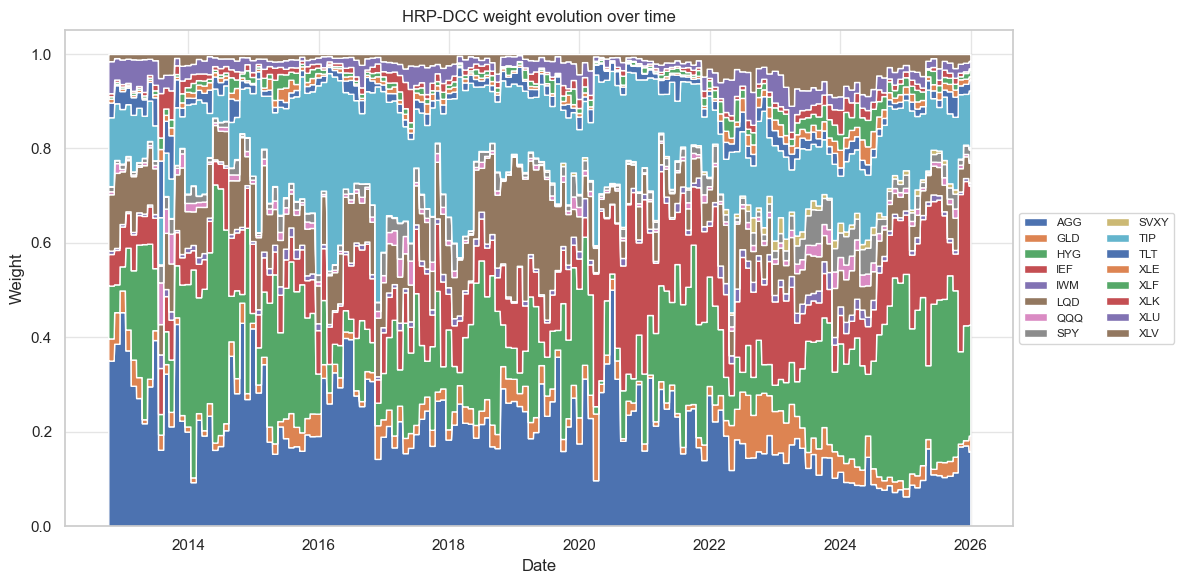

In [47]:
plt.figure(figsize=(12, 6))
plt.stackplot(weights_df.index, weights_df.values.T, labels=weights_df.columns)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), ncol=2, fontsize="x-small")
plt.title("HRP-DCC weight evolution over time")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()

In [48]:
# Interpretation:
# The weight evolution plot confirms that the heavy fixed-income
# concentration observed in Section 4 (for the last day) is a
# persistent feature throughout the entire backtest, not a one-off
# snapshot: AGG, HYG, TIP, and LQD together consistently account for
# roughly 70-90% of the portfolio across most rebalancing dates, while
# equity ETFs (SPY, QQQ, IWM, sector funds) occupy a comparatively
# small and unstable share. The allocation is also highly jagged from
# one rebalance to the next, indicating substantial turnover rather
# than smooth, persistent tilts - consistent with HRP's sensitivity to
# shifts in the estimated covariance structure at each rebalance.
#
# The equity curve makes the practical consequence of this concentration
# clear: HRP-DCC (blue) tracks well below all three benchmarks for
# almost the entire sample, ending around a 1.47x cumulative return
# versus roughly 2.47x for Equal-Weight and ~1.5-1.6x for Static HRP
# and Min-Variance. Static HRP and Min-Variance move very closely
# together throughout, both consistently ahead of HRP-DCC - reinforcing
# the Section 4 finding that the dynamic DCC-GARCH covariance estimate,
# rather than the HRP algorithm itself, is the main driver of
# HRP-DCC's underperformance in this backtest.

In [ ]:
# ============================================================
# SECTION 6: Conclusions
# ============================================================

In [ ]:
# Summary of findings:
#
# 1. Data & GARCH: Returns exhibit significant excess kurtosis and
#    fat tails (confirmed by the Jarque-Bera test), justifying the
#    use of a Student-t GARCH(1,1) specification. Univariate GARCH
#    models fit cleanly for most assets, with SVXY as a notable
#    exception (alpha+beta ~= 1.0, close to IGARCH), consistent with
#    its highly asymmetric, shock-prone nature as a short-VIX ETF.
#
# 2. DCC correlation dynamics: The fitted DCC model shows high
#    persistence (alpha+beta ~= 0.99 on the full sample), meaning
#    correlation shocks decay slowly. Comparing DCC correlations to a
#    simple rolling-window correlation showed that this smoothing
#    effect is a general property of the model across the entire
#    sample, not something specific to the COVID-19 period as
#    initially expected.
#
# 3. DCC estimation instability: Diagnostics revealed that the
#    original Nelder-Mead optimizer occasionally collapsed to
#    degenerate solutions (alpha+beta ~= 0) on a handful of early
#    training windows, despite clean input data. This was mitigated
#    via a multi-start optimization and a fallback mechanism. After
#    the fix, backtest performance metrics were virtually unchanged,
#    confirming that the underperformance of HRP-DCC documented below
#    is not an artifact of this instability.
#
# 4. Portfolio structure: The HRP dendrogram groups assets in an
#    economically sensible way (fixed income vs. equities, with HYG
#    grouping with equities due to its equity-like credit risk).
#    However, the resulting HRP-DCC allocation is heavily concentrated
#    in fixed income (AGG, HYG, IEF, TIP, LQD), persistently accounting
#    for roughly 70-90% of the portfolio throughout the backtest.
#
# 5. Backtest performance: HRP-DCC underperforms all three benchmarks
#    on risk-adjusted metrics (Sharpe 0.26 vs. 0.32-0.49 for the
#    benchmarks), despite having the lowest volatility. Equal-Weight
#    is the strongest performer on Sharpe and Calmar ratio, consistent
#    with the well-documented difficulty of beating naive 1/N
#    diversification out-of-sample. Static HRP (Ledoit-Wolf) and
#    Min-Variance perform similarly to each other and both outperform
#    HRP-DCC, suggesting that the dynamic DCC-GARCH covariance
#    estimate - rather than the HRP allocation algorithm itself - is
#    the main driver of HRP-DCC's weaker performance in this backtest.
#
# Possible directions for extension:
# - Transaction costs are not modeled; given HRP-DCC's high turnover
#   (visible in the jagged weight evolution plot), including costs
#   would likely widen the performance gap further.
# - The DCC estimation could be made more robust (e.g. gradient-based
#   optimization with parameter transformation instead of Nelder-Mead).
# - Shifting the backtest start date to avoid the earliest, data-sparse
#   period (shortly after SVXY's 2011 inception) could be tested to
#   see whether it removes the need for the DCC fallback mechanism.